In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [2]:
image_path = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg'
mask_path = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg'
image_path, mask_path


('/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg',
 '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg')

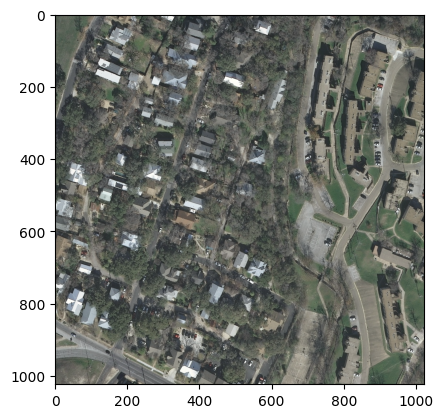

In [3]:
image = cv2.imread(image_path)

plt.imshow(image)
plt.show()

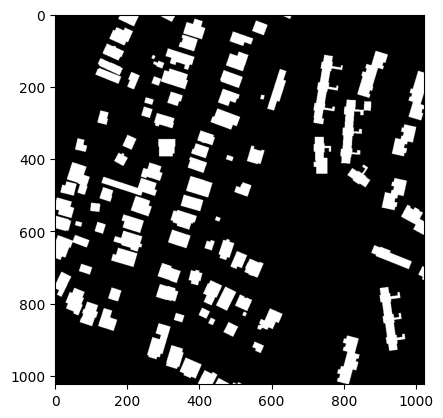

In [4]:
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap="gray")
plt.show()

In [5]:
image.shape, mask.shape

((1024, 1024, 3), (1024, 1024))

In [6]:
## YOLO V10 - SAM


0: 640x640 81 0s, 2.6ms
Speed: 1.1ms preprocess, 2.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([1, 1024, 1024])
[np.int64(532), np.int64(673), np.int64(587), np.int64(729)]


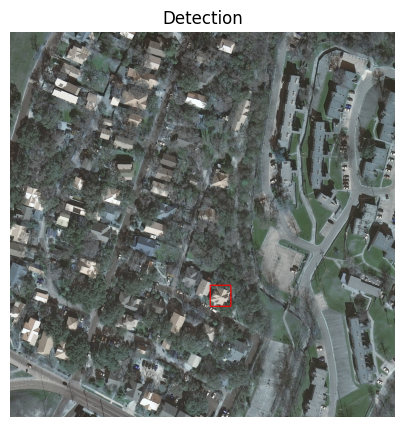

<Figure size 640x480 with 0 Axes>

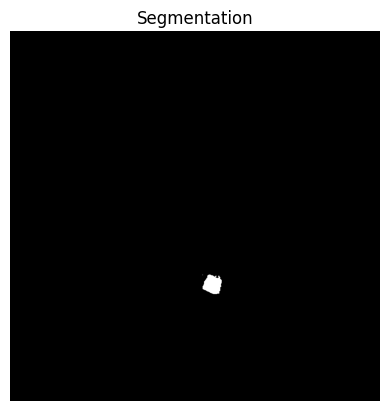

In [26]:
yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/YOLOs/yolov10/v_10best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

image_with_boxes = image.copy()


for box in boxes[:1]:
    x1, y1, x2, y2 = box.astype(int)  
    point = [x1, y1, x2, y2 ]
    rect = cv2.rectangle(image_with_boxes,(x1, y1), (x2 , y2), (0,0,255), 2)

print(point)

image_with_boxes = cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title("Detection")
plt.imshow(image_with_boxes)
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images/image_with_boxes.png")
plt.show()


for box in boxes[:1]:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

# titles = ["Original Image", "Ground Truth","YOLOv10 + SAM"]

# images = [
#     image,
#     gt_mask.cpu().numpy(),
#     combined_mask.cpu().numpy()[0]
# ]

# plt.figure(figsize=(15, 10))
# for i, (img, title) in enumerate(zip(images, titles)):
#     plt.subplot(1, 3, i + 1)
#     plt.imshow(img, cmap='gray' if i != 0 else None)
#     plt.title(title)
#     plt.axis('off')

plt.tight_layout()
# plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images/yolov12_sam_predicted_mask.png")
plt.show()

plt.Figure((5,5))
plt.title("Segmentation")
plt.axis('off')
plt.imshow(combined_mask.cpu().numpy()[0], cmap="gray")
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images/image_with_segmentation.png")
plt.show()


In [ ]:
## YOLOv11 + SAM

In [ ]:
yolo_model = YOLO("/home/selc-a4-sr2/Solar_Rooftop_Detection/YOLOs/YOLOV_11/best.pt")
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv11 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
# plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov11_sam_predicted_mask.png")
plt.show()


## YOLO v12 + SAM


0: 640x640 81 0s, 2.7ms
Speed: 1.1ms preprocess, 2.7ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([1, 1024, 1024])


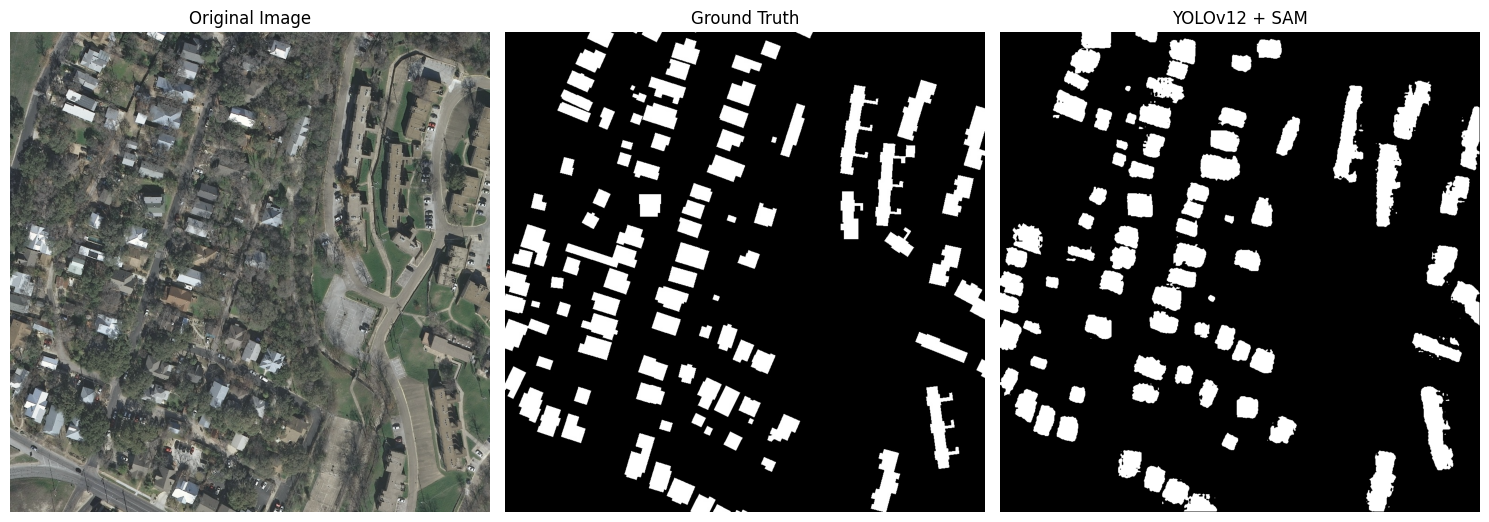

In [ ]:
yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/YOLOs/yolov10/v_10best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv12 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
# plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov12_sam_predicted_mask.png")
plt.show()


In [ ]:
## DETR + SAM

In [ ]:
from rfdetr import RFDETRBase

In [ ]:
checkpoint_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/DETR/rfdetrf.pth"  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wrapper = RFDETRBase()
underlying_model = model_wrapper.model
underlying_model.reinitialize_detection_head(num_classes=2)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
pytorch_model = underlying_model.model
pytorch_model.load_state_dict(checkpoint['model'])

pytorch_model.to(device)
pytorch_model.eval()

sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
detections = model_wrapper.predict(image, threshold=0.5)
boxes = detections.xyxy

# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","DETR + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/DETR_sam_predicted_mask.png")
plt.show()


In [ ]:
## UNet model

In [ ]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image


In [ ]:
os.getcwd()

In [ ]:
os.chdir('../')
os.getcwd()

In [ ]:
from BaseLineModels.Unet_model.Unet_model import UNet

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image


In [ ]:
image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)



my_model = UNet()
my_model.load_state_dict(torch.load("/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/Unet_model/unet_rooftop_50.pth"))
my_model.to(device=device)
my_model.eval()

with torch.no_grad():
    unet_out = my_model(image_batch)  # (1, 1, H, W)
    
    unet_mask = (unet_out > 0.5).float()

def to_numpy(t):
    return t.squeeze().detach().cpu().numpy()

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = to_numpy(mask)
pred_mask_np = to_numpy(unet_mask) 

titles = ["Original Image", "Ground Truth","UNET Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/UNET_predicted_mask.png")
plt.show()

In [ ]:
## DeepLabV3

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [2]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

(1, 1, 1024, 1024)


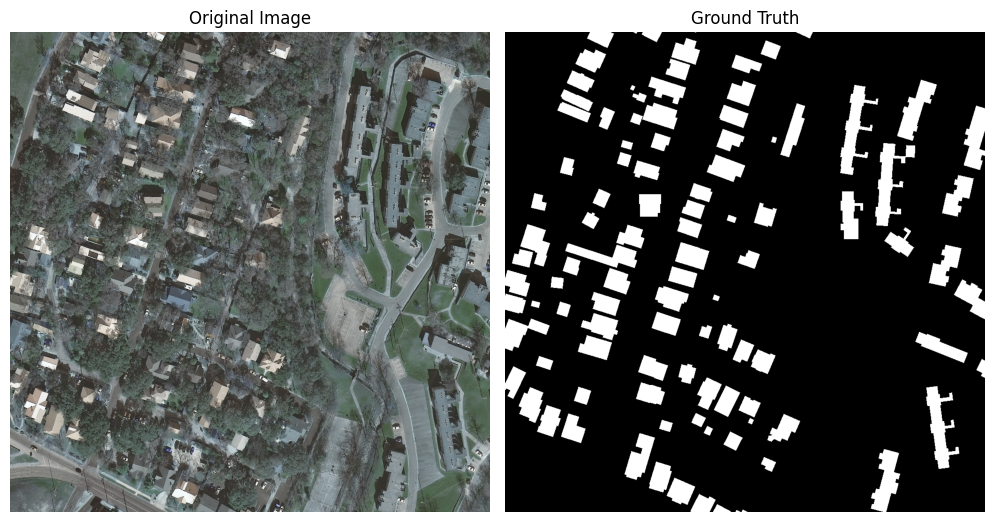

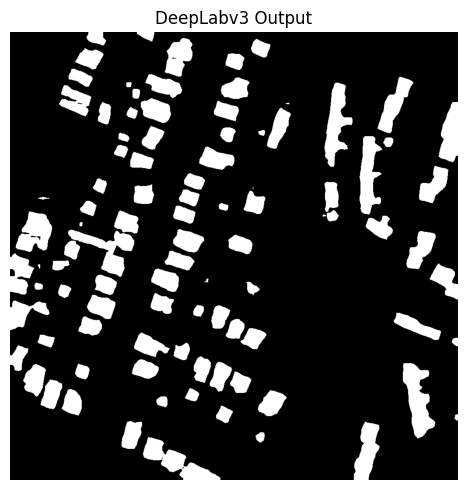

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)


model = torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/BaseLineModels/deeplabv3/deeplab_rooftop_full_50.pth", weights_only=False)
model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(image_batch)["out"]
    preds = torch.sigmoid(outputs) > 0.5
    preds = preds.cpu().numpy().astype(np.uint8)

print(preds.shape)

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = mask.reshape(1024,1024)
pred_mask_np = preds.reshape(1024,1024)

titles = ["Original Image", "Ground Truth","DeepLabv3 Output"]

images = [
    original_np,
    gt_mask_np,
    
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images/DEEPLABV3_predicted_mask.png")
plt.show()


plt.figure(figsize=(5, 5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images/DEEPLABV3_mask_only.png")
plt.show()



In [ ]:
## Mask RCNN

In [ ]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as TF
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
ground_mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)

model_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/Maksed_RCNN/mask_rcnn_epoch_50_full.pth"
my_model = torch.load(model_path)
my_model.to(device)
my_model.eval()


with torch.no_grad():
    output = my_model(image_batch)[0]

keep = output["scores"] >= 0.5
boxes = output["boxes"][keep].cpu().numpy()
labels = output["labels"][keep].cpu().numpy()
masks = output["masks"][keep].squeeze(1).cpu().numpy()  # Shape: (N, H, W)

final_mask = torch.zeros((1024,1024), dtype=torch.float32)

for mask in masks:
    bin_mask = (mask > 0.5).astype(np.uint8)
    bin_mask_pil = TF.to_pil_image(bin_mask)
    resized_mask = TF.to_tensor(TF.resize(bin_mask_pil, (1024,1024))).squeeze(0)
    
    # Combine using logical OR
    final_mask = torch.logical_or(final_mask, resized_mask).float()
    
    
original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = ground_mask.reshape(1024,1024)
pred_mask_np = final_mask

titles = ["Original Image", "Ground Truth","MaskRCNN Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/MaskRCNN_predicted_mask.png")
plt.show()

## Tset Indian images YOLO v12 + SAM


0: 1024x1024 3 0s, 8.5ms
Speed: 9.3ms preprocess, 8.5ms inference, 100.6ms postprocess per image at shape (1, 3, 1024, 1024)
torch.Size([1, 1024, 1024])


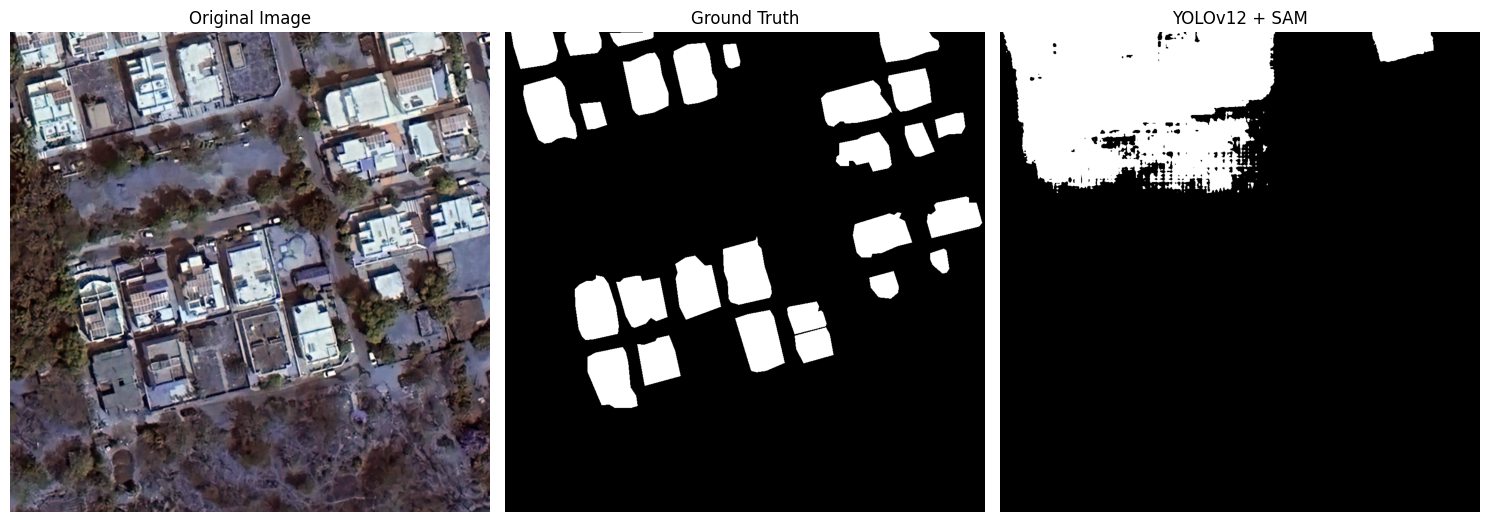

In [1]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns


image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_0.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/mask_sample_0.png"


image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

yolo_model = YOLO("/home/selc-a4-sr2/Solar_Rooftop_Detection/YOLOs/yolov12/best.pt")
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv12 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images_indian_images/yolov12_sam_predicted_mask.png")
plt.show()


# UNET Test on indian images

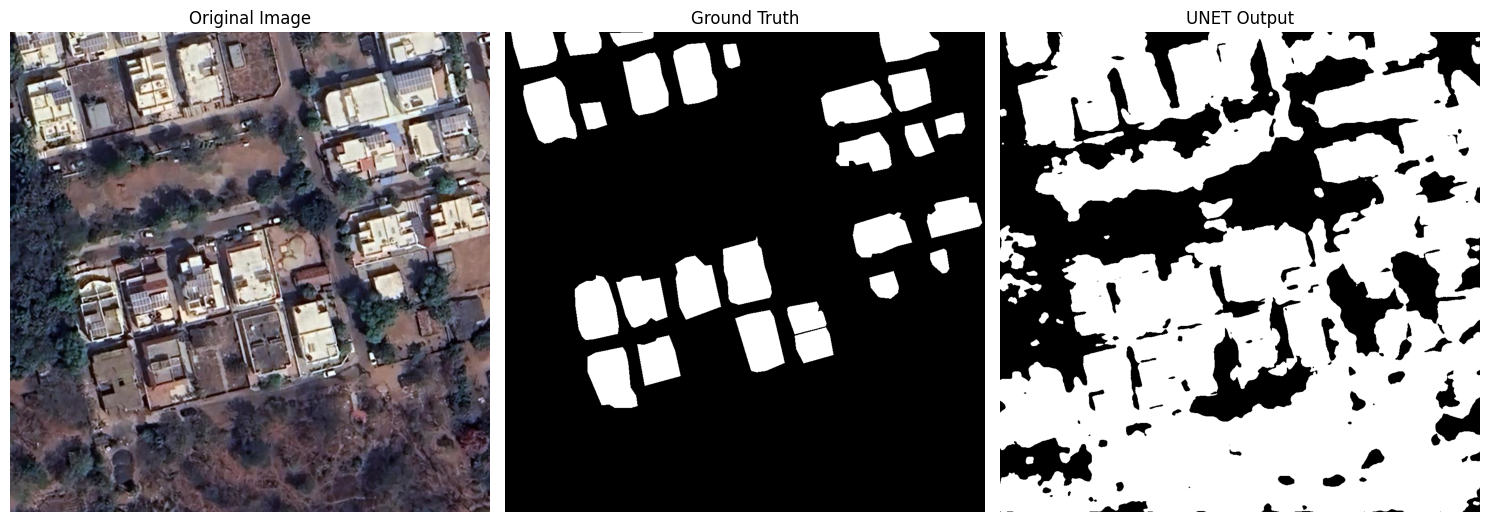

In [2]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image

os.chdir('../')
os.getcwd()

from BaseLineModels.Unet_model.Unet_model import UNet

image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_0.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/mask_sample_0.png"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = mask*255
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)



my_model = UNet()
my_model.load_state_dict(torch.load("/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/Unet_model/unet_rooftop_50.pth"))
my_model.to(device=device)
my_model.eval()

with torch.no_grad():
    unet_out = my_model(image_batch)  # (1, 1, H, W)
    
    unet_mask = (unet_out > 0.5).float()

def to_numpy(t):
    return t.squeeze().detach().cpu().numpy()

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = to_numpy(mask)
gt_mask_np = gt_mask_np * 255
pred_mask_np = to_numpy(unet_mask) 

titles = ["Original Image", "Ground Truth","UNET Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images_indian_images/UNET_predicted_mask.png")
plt.show()

In [ ]:
np.unique(gt_mask_np)


0: 640x640 1 0, 2.5ms
Speed: 1.2ms preprocess, 2.5ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([1, 1024, 1024])
[np.int64(144), np.int64(413), np.int64(707), np.int64(831)]


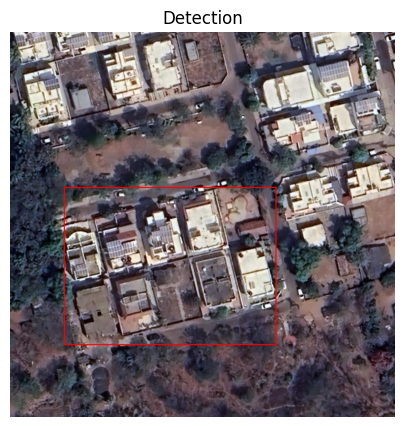

<Figure size 640x480 with 0 Axes>

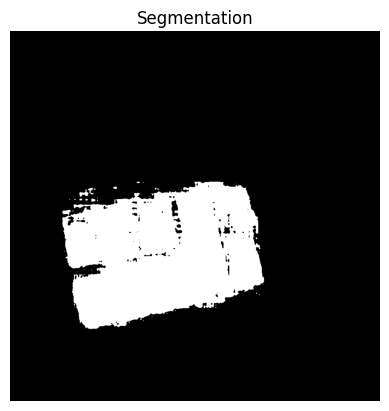

In [3]:

import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns

image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/sample_0.jpg"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/Demo_images/mask_sample_0.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)


yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/YOLOs/yolov10/v_10best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# # print(boxes)
# print(mask.shape)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

image_with_boxes = image.copy()


for box in boxes:
    x1, y1, x2, y2 = box.astype(int)  
    point = [x1, y1, x2, y2 ]
    rect = cv2.rectangle(image_with_boxes,(x1, y1), (x2 , y2), (0,0,255), 2)

print(point)

image_with_boxes = cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title("Detection")
plt.imshow(image_with_boxes)
# plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images_indian_images/image_with_boxes.png")
plt.show()


for box in boxes[:1]:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

# titles = ["Original Image", "Ground Truth","YOLOv10 + SAM"]

# images = [
#     image,
#     gt_mask.cpu().numpy(),
#     combined_mask.cpu().numpy()[0]
# ]

# plt.figure(figsize=(15, 10))
# for i, (img, title) in enumerate(zip(images, titles)):
#     plt.subplot(1, 3, i + 1)
#     plt.imshow(img, cmap='gray' if i != 0 else None)
#     plt.title(title)
#     plt.axis('off')

plt.tight_layout()
# plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images_indian_images/yolov12_sam_predicted_mask.png")
plt.show()

plt.Figure((5,5))
plt.title("Segmentation")
plt.axis('off')
plt.imshow(combined_mask.cpu().numpy()[0], cmap="gray")
# plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/output_images_indian_images/image_with_segmentation.png")
plt.show()
